In [58]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

In [59]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("dataset\\"):
    sub_folder_files = os.listdir(os.path.join("dataset\\", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset\\", sub_folder, filename)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(filename)[0]
        file_name.append(filename)
        
data = np.array(data)
labels = np.array(labels)


In [60]:
daunAsli1 = cv.cvtColor(cv.imread('dataset/daun_sehat_100/0ac4ff49-7fbf-4644-98a4-4dc596e2fa87___Mt.N.V_HL 9004.jpg'), cv.COLOR_BGR2RGB)
daunAsli2 = cv.cvtColor(cv.imread('dataset/daun_sehat_100/0c1667a2-61d7-4dee-b4d9-0d141a1ceb20___Mt.N.V_HL 9127.jpg'), cv.COLOR_BGR2RGB)
daunAsli3 = cv.cvtColor(cv.imread('dataset/daun_sehat_100/0ca59865-f0d2-4863-b4d1-a6690de53a5a___Mt.N.V_HL 6025.jpg'), cv.COLOR_BGR2RGB)
sakit1 = cv.cvtColor(cv.imread('dataset/Grape_black_rot_100/Grape_Black_rot1.jpg'), cv.COLOR_BGR2RGB)
sakit2 = cv.cvtColor(cv.imread('dataset/Grape_black_rot_100/Grape_Black_rot101.jpg'), cv.COLOR_BGR2RGB)
sakit3 = cv.cvtColor(cv.imread('dataset/Grape_black_rot_100/Grape_Black_rot102.jpg'), cv.COLOR_BGR2RGB)

daunSehat1 = cv.resize(daunAsli1, (256, 256))
daunSehat2 = cv.resize(daunAsli2, (256, 256))
daunSehat3 = cv.resize(daunAsli3, (256, 256))
rot1 = cv.resize(sakit1, (256, 256))
rot2 = cv.resize(sakit2, (256, 256))
rot3 = cv.resize(sakit3, (256, 256))

daun1 = cv.cvtColor(daunSehat1, cv.COLOR_RGB2GRAY)
daun2 = cv.cvtColor(daunSehat2, cv.COLOR_RGB2GRAY)
daun3 = cv.cvtColor(daunSehat3, cv.COLOR_RGB2GRAY)
daunSakit1 = cv.cvtColor(rot1, cv.COLOR_RGB2GRAY)
daunSakit2 = cv.cvtColor(rot2, cv.COLOR_RGB2GRAY)
daunSakit3 = cv.cvtColor(rot3, cv.COLOR_RGB2GRAY)

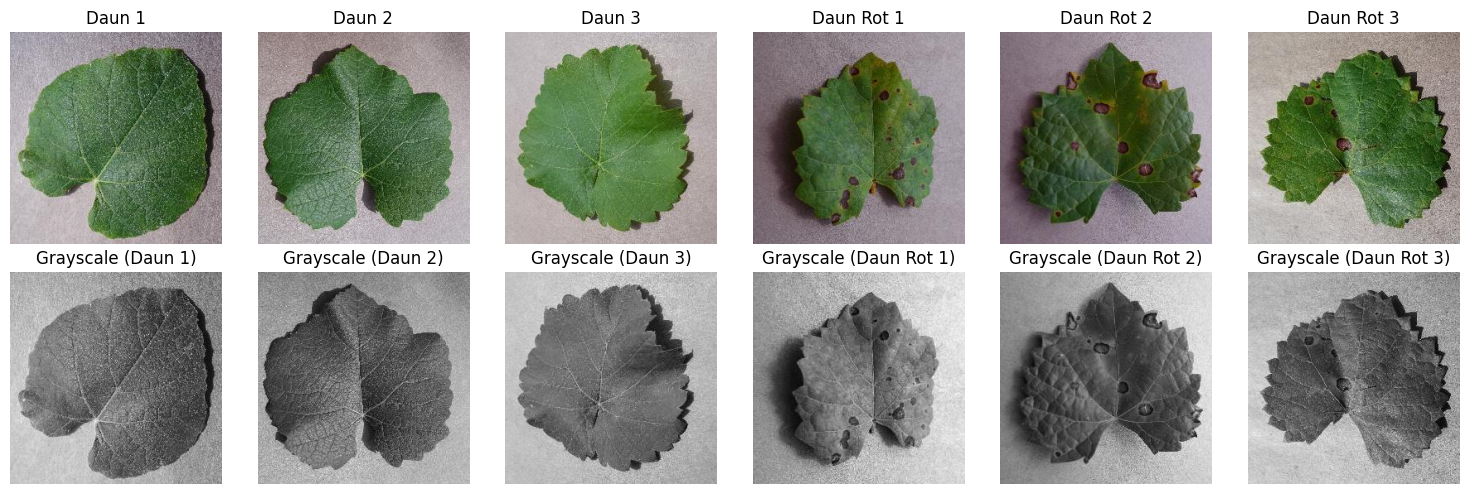

In [61]:
plt.figure(figsize=(15,5))

plt.subplot(2,6,1)
plt.title("Daun 1")
plt.imshow(daunSehat1, cmap='gray')
plt.axis('off')

plt.subplot(2,6,2)
plt.title("Daun 2")
plt.imshow(daunSehat2, cmap='gray')
plt.axis('off')

plt.subplot(2,6,3)
plt.title("Daun 3")
plt.imshow(daunSehat3, cmap='gray')
plt.axis('off')


plt.subplot(2,6,4)
plt.title("Daun Rot 1")
plt.imshow(rot1, cmap='gray')
plt.axis('off')

plt.subplot(2,6,5)
plt.imshow(rot2, cmap='gray')
plt.title("Daun Rot 2")
plt.axis('off')

plt.subplot(2,6,6)
plt.title("Daun Rot 3")
plt.imshow(rot3, cmap='gray')
plt.axis('off')

plt.subplot(2,6,7)
plt.title("Grayscale (Daun 1)")
plt.imshow(daun1, cmap='gray')
plt.axis('off')

plt.subplot(2,6,8)
plt.title("Grayscale (Daun 2)")
plt.imshow(daun2, cmap='gray')
plt.axis('off')

plt.subplot(2,6,9)
plt.title("Grayscale (Daun 3)")
plt.imshow(daun3, cmap='gray')
plt.axis('off')

plt.subplot(2,6,10)
plt.title("Grayscale (Daun Rot 1)")
plt.imshow(daunSakit1, cmap='gray')
plt.axis('off')

plt.subplot(2,6,11)
plt.imshow(daunSakit2, cmap='gray')
plt.title("Grayscale (Daun Rot 2)")
plt.axis('off')

plt.subplot(2,6,12)
plt.title("Grayscale (Daun Rot 3)")
plt.imshow(daunSakit3, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


## Data Augmentation

### Define Augmentation Function


In [62]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
	pass

In [63]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  200
Data setelah augmentasi:  0


## Data Preparation

### Define Preprocessing Function


In [64]:
TARGET_SIZE = (256, 256)

def resize(image, target_size):
    return cv.resize(image, target_size, interpolation=cv.INTER_LINEAR)

# Prepro 1: Resize → Grayscale → Median Filter
def prepro1(image):
    img = resize(image, TARGET_SIZE)
    # Pastikan grayscale (data sudah grayscale dari loading, tapi jaga-jaga)
    if len(img.shape) == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = cv.medianBlur(img, 5)  # kernel 5x5
    return img

# Prepro 2: Resize → Grayscale → Histogram Equalization → Median Filter
def prepro2(image):
    img = resize(image, TARGET_SIZE)
    if len(img.shape) == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = cv.equalizeHist(img)   # Histogram Equalization
    img = cv.medianBlur(img, 5)  # Median Filter
    return img

# Prepro 3: Resize → Grayscale → Median Filter → Sobel → Roberts
def prepro3(image):
    img = resize(image, TARGET_SIZE)
    if len(img.shape) == 3:
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = cv.medianBlur(img, 5)  # Median Filter

    # Sobel (gabungan X dan Y)
    sobelX = cv.Sobel(img, cv.CV_64F, 1, 0, ksize=3)
    sobelY = cv.Sobel(img, cv.CV_64F, 0, 1, ksize=3)
    sobel  = cv.magnitude(sobelX, sobelY)
    sobel  = np.clip(sobel, 0, 255).astype(np.uint8)

    # Roberts (manual dengan kernel)
    kernelRx = np.array([[1, 0], [0, -1]], dtype=np.float64)
    kernelRy = np.array([[0, 1], [-1, 0]], dtype=np.float64)
    robertsX = cv.filter2D(sobel.astype(np.float64), -1, kernelRx)
    robertsY = cv.filter2D(sobel.astype(np.float64), -1, kernelRy)
    roberts  = np.sqrt(robertsX**2 + robertsY**2)
    roberts  = np.clip(roberts, 0, 255).astype(np.uint8)

    return roberts

### Preprocessing

In [ ]:
# pada bagian ini bisa gunakan data yang sebelum augmentasi atau setelah augmentasi
# Ganti 'data' dengan 'data_augmented' jika ingin pakai hasil augmentasi
# Ganti 'prepro1' dengan 'prepro2' atau 'prepro3' sesuai metode yang dipakai

PREPRO_CHOICE = 1  # Ganti 1, 2, atau 3 sesuai metode preprocessing yang dipilih

prepro_fn = {1: prepro1, 2: prepro2, 3: prepro3}[PREPRO_CHOICE]

dataPreprocessed = []
for i in range(len(data)):
    processed = prepro_fn(data[i])
    dataPreprocessed.append(processed)


Preprocessing selesai dengan prepro1
Jumlah data: 200, Shape tiap gambar: (256, 256)


### Feature Extraction

In [66]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [67]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

In [68]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

In [69]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

In [70]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

In [71]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

In [72]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

In [73]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [74]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [75]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


In [76]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [77]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [78]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [79]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [80]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [81]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [82]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Write the extraction's results to CSV 

In [83]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_...,daun_sehat_100,29.397074,52.360707,23.538909,38.817332,0.585496,0.497931,0.598071,0.505807,...,0.004500,0.003279,0.066603,0.056624,0.067080,0.057260,0.987045,0.976902,0.989634,0.982876
1,02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_...,daun_sehat_100,41.781771,68.430250,36.362331,65.325536,0.441705,0.356804,0.466834,0.362053,...,0.002242,0.001460,0.044672,0.037543,0.047353,0.038216,0.986650,0.978154,0.988386,0.979146
2,05cff9d7-0f63-4b6e-9aa3-199cf9ffa64c___Mt.N.V_...,daun_sehat_100,28.830699,50.334241,27.468490,44.424621,0.490187,0.384575,0.478488,0.386837,...,0.001571,0.001088,0.040621,0.032959,0.039642,0.032989,0.989263,0.981236,0.989750,0.983439
3,07c7232b-5cdb-4bab-9413-e0108a48526f___Mt.N.V_...,daun_sehat_100,19.598897,34.473956,20.275720,33.814010,0.514176,0.420696,0.516305,0.412149,...,0.001951,0.001319,0.043768,0.036760,0.044172,0.036322,0.990932,0.984042,0.990616,0.984348
4,07d28aaf-09ea-4223-9a65-88ef49e54924___Mt.N.V_...,daun_sehat_100,40.774403,60.203998,29.098284,58.284460,0.424716,0.333972,0.452438,0.343440,...,0.001015,0.000647,0.030489,0.025075,0.031855,0.025444,0.987126,0.980966,0.990795,0.981574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Grape_Black_rot1064.jpg,Grape_black_rot_100,20.363542,32.248458,20.409161,38.922276,0.461048,0.389912,0.466322,0.356290,...,0.001445,0.000934,0.037856,0.032743,0.038017,0.030569,0.991412,0.986359,0.991365,0.983536
196,Grape_Black_rot10640.jpg,Grape_black_rot_100,16.670205,37.925798,26.877114,39.790250,0.491891,0.368929,0.444683,0.373327,...,0.001149,0.000878,0.037215,0.029360,0.033893,0.029639,0.994352,0.987112,0.990892,0.986479
197,Grape_Black_rot10641.jpg,Grape_black_rot_100,16.641483,39.735363,26.830607,37.853795,0.492287,0.373877,0.445733,0.369489,...,0.001149,0.000863,0.037150,0.029658,0.033904,0.029379,0.994362,0.986497,0.990908,0.987136
198,Grape_Black_rot10642.jpg,Grape_black_rot_100,16.671400,39.788435,26.877880,37.930534,0.491966,0.373494,0.444618,0.369094,...,0.001148,0.000863,0.037222,0.029665,0.033888,0.029383,0.994352,0.986480,0.990892,0.987111


### Features Selection

pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:

<Axes: >

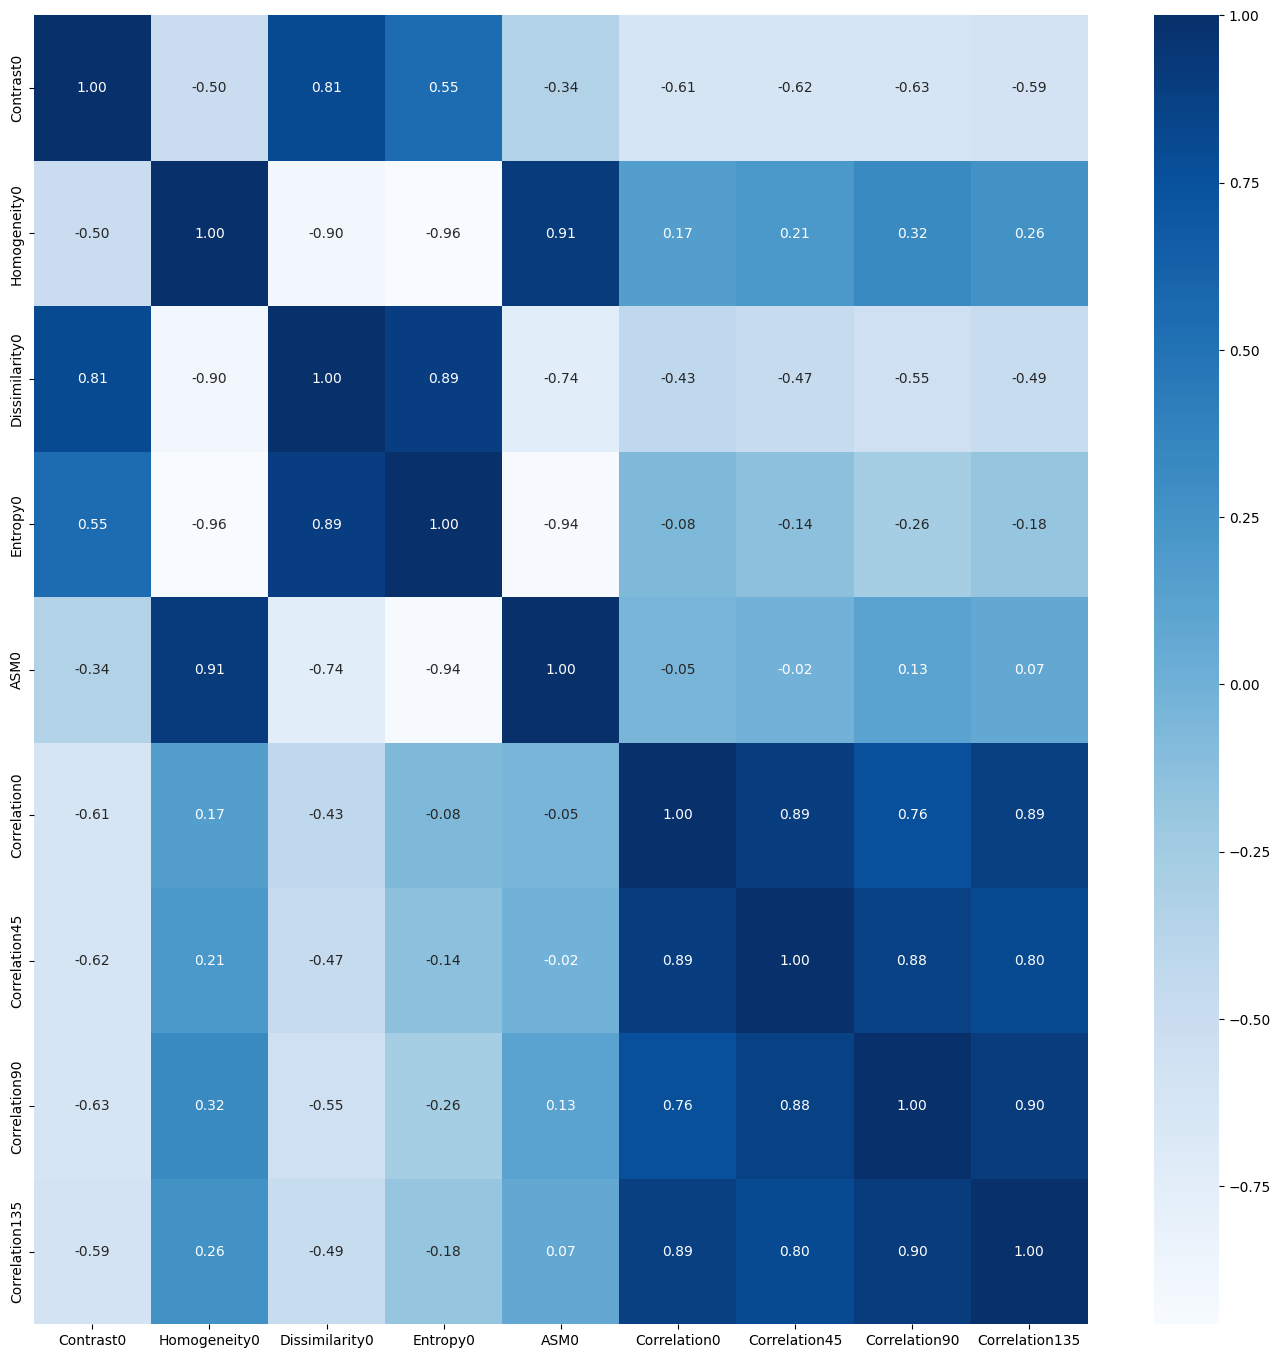

In [84]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Splitting Data

In [85]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(160, 9)
(40, 9)


## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

In [86]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

In [87]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [88]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.99      1.00      0.99        81
     daun_sehat_100       1.00      0.99      0.99        79

           accuracy                           0.99       160
          macro avg       0.99      0.99      0.99       160
       weighted avg       0.99      0.99      0.99       160

[[81  0]
 [ 1 78]]
Accuracy: 0.99375

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       1.00      0.95      0.97        19
     daun_sehat_100       0.95      1.00      0.98        21

           accuracy                           0.97        40
          macro avg       0.98      0.97      0.97        40
       weighted avg       0.98      0.97      0.97        40

[[18  1]
 [ 0 21]]
Accuracy: 0.975


### Train SVM Classifier

In [89]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.89      0.96      0.92        81
     daun_sehat_100       0.96      0.87      0.91        79

           accuracy                           0.92       160
          macro avg       0.92      0.92      0.92       160
       weighted avg       0.92      0.92      0.92       160

[[78  3]
 [10 69]]
Accuracy: 0.91875

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.95      0.92        19
     daun_sehat_100       0.95      0.90      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.93      0.92        40
       weighted avg       0.93      0.93      0.93        40

[[18  1]
 [ 2 19]]
Accuracy: 0.925


### Train KNN Classifier

In [90]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.93      0.91        81
     daun_sehat_100       0.92      0.90      0.91        79

           accuracy                           0.91       160
          macro avg       0.91      0.91      0.91       160
       weighted avg       0.91      0.91      0.91       160

[[75  6]
 [ 8 71]]
Accuracy: 0.9125

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.95      0.92        19
     daun_sehat_100       0.95      0.90      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.93      0.92        40
       weighted avg       0.93      0.93      0.93        40

[[18  1]
 [ 2 19]]
Accuracy: 0.925


## Evaluation With Confusion Matrix

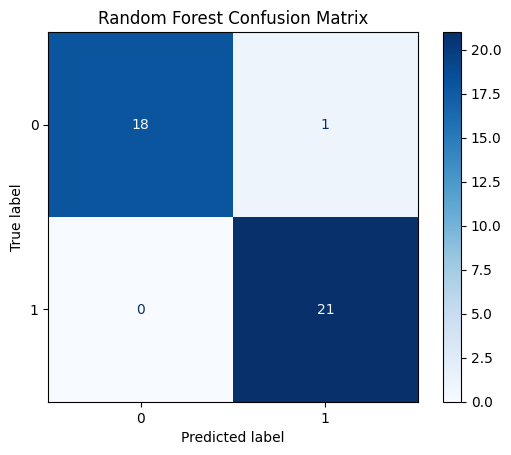

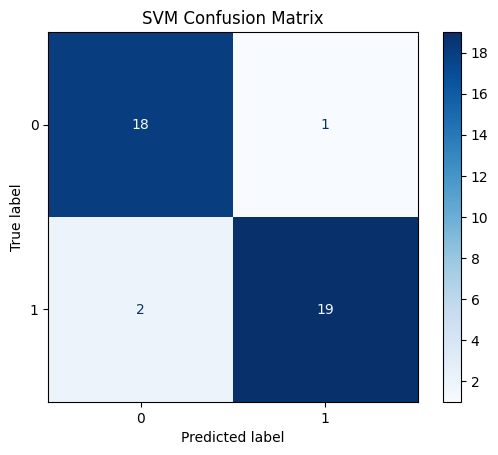

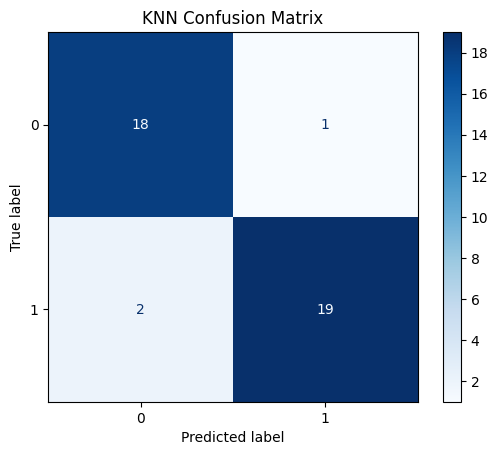

In [91]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")